<a href="https://colab.research.google.com/github/cryonixx/Data_Baes_DeepLearning_Codes/blob/main/Experiment_1_Redemption_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil

os.environ['KAGGLE_API_TOKEN'] = "KGAT_050ee8708b6181fc2b0c80c381279921"
print("Authenticating with Kaggle...")

dataset_zip = 'wesad-wearable-stress-affect-detection-dataset.zip'
dataset_dir = 'wesad_data/'

# Remove existing data if it exists to ensure a fresh download
if os.path.exists(dataset_dir):
    print(f"Removing existing directory: {dataset_dir}")
    shutil.rmtree(dataset_dir)
if os.path.exists(dataset_zip):
    print(f"Removing existing zip file: {dataset_zip}")
    os.remove(dataset_zip)

print("Downloading WESAD Dataset...")
!kaggle datasets download -d orvile/wesad-wearable-stress-affect-detection-dataset --force

print("Unzipping WESAD Dataset...")
!unzip -q -o {dataset_zip} -d {dataset_dir}

print("WESAD Dataset downloaded and unzipped successfully!")

Authenticating with Kaggle...
Dataset URL: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.43G/2.43G [02:19<00:00, 18.8MB/s]

Unzipping WESAD Dataset...
WESAD Dataset downloaded and unzipped successfully!


In [ ]:
# Dataset Loading (Original code) (By Ritch)
'''import pickle
import numpy as np

def load_wesad_subject(file_path):
    with open(file_path, 'rb') as f:
        # WESAD uses 'latin1' encoding for its pickles
        data = pickle.load(f, encoding='latin1')

    # Extract ECG from the chest sensor
    ecg_signal = data['signal']['chest']['ECG'].flatten()
    labels = data['label']

    # Filter only for Neutral (1) and Stress (2)
    valid_indices = np.where((labels == 1) | (labels == 2))[0]

    filtered_ecg = ecg_signal[valid_indices]
    filtered_labels = labels[valid_indices]

    # Convert label '2' (Stress) to 1, and '1' (Neutral) to 0 for Binary Classification
    filtered_labels = np.where(filtered_labels == 2, 1, 0)

    return filtered_ecg, filtered_labels

# Usage
file_path = 'wesad_data/WESAD/S2/S2.pkl'
ecg, y = load_wesad_subject(file_path)'''

"import pickle\nimport numpy as np\n\ndef load_wesad_subject(file_path):\n    with open(file_path, 'rb') as f:\n        # WESAD uses 'latin1' encoding for its pickles\n        data = pickle.load(f, encoding='latin1')\n\n    # Extract ECG from the chest sensor\n    ecg_signal = data['signal']['chest']['ECG'].flatten()\n    labels = data['label']\n\n    # Filter only for Neutral (1) and Stress (2)\n    valid_indices = np.where((labels == 1) | (labels == 2))[0]\n\n    filtered_ecg = ecg_signal[valid_indices]\n    filtered_labels = labels[valid_indices]\n\n    # Convert label '2' (Stress) to 1, and '1' (Neutral) to 0 for Binary Classification\n    filtered_labels = np.where(filtered_labels == 2, 1, 0)\n\n    return filtered_ecg, filtered_labels\n\n# Usage\nfile_path = 'wesad_data/WESAD/S2/S2.pkl'\necg, y = load_wesad_subject(file_path)"

In [ ]:
# Data Normalization (Original Code) (By Quiel)
'''from sklearn.preprocessing import StandardScaler
import numpy as np

def process_subject(file_path, window_size=7000, step_size=3500):
    # load and filter
    raw_ecg, raw_labels = load_wesad_subject(file_path)
    filtered_ecg, filtered_labels = filter_data_neutral_only(raw_ecg, raw_labels)

    # normalize across the whole signal
    scaler = StandardScaler()
    normalized_ecg = scaler.fit_transform(filtered_ecg.reshape(-1, 1)).flatten()

    # rolling window
    X, y = [], []
    for start in range(0, len(normalized_ecg) - window_size + 1, step_size):
        window = normalized_ecg[start:start + window_size]
        label = filtered_labels[start:start + window_size]
        majority_label = np.bincount(label.astype(int)).argmax()
        X.append(window.reshape(-1, 1))
        y.append(majority_label)

    return np.array(X), np.array(y)

# usage
X, y = process_subject('wesad_data/WESAD/S2/S2.pkl')
print(f"X shape: {X.shape}, y shape: {y.shape}")'''

'from sklearn.preprocessing import StandardScaler\nimport numpy as np\n\ndef process_subject(file_path, window_size=7000, step_size=3500):\n    # load and filter\n    raw_ecg, raw_labels = load_wesad_subject(file_path)\n    filtered_ecg, filtered_labels = filter_data_neutral_only(raw_ecg, raw_labels)\n\n    # normalize across the whole signal\n    scaler = StandardScaler()\n    normalized_ecg = scaler.fit_transform(filtered_ecg.reshape(-1, 1)).flatten()\n\n    # rolling window\n    X, y = [], []\n    for start in range(0, len(normalized_ecg) - window_size + 1, step_size):\n        window = normalized_ecg[start:start + window_size]\n        label = filtered_labels[start:start + window_size]\n        majority_label = np.bincount(label.astype(int)).argmax()\n        X.append(window.reshape(-1, 1))\n        y.append(majority_label)\n\n    return np.array(X), np.array(y)\n\n# usage\nX, y = process_subject(\'wesad_data/WESAD/S2/S2.pkl\')\nprint(f"X shape: {X.shape}, y shape: {y.shape}")'

# DATA PREPROCESSING

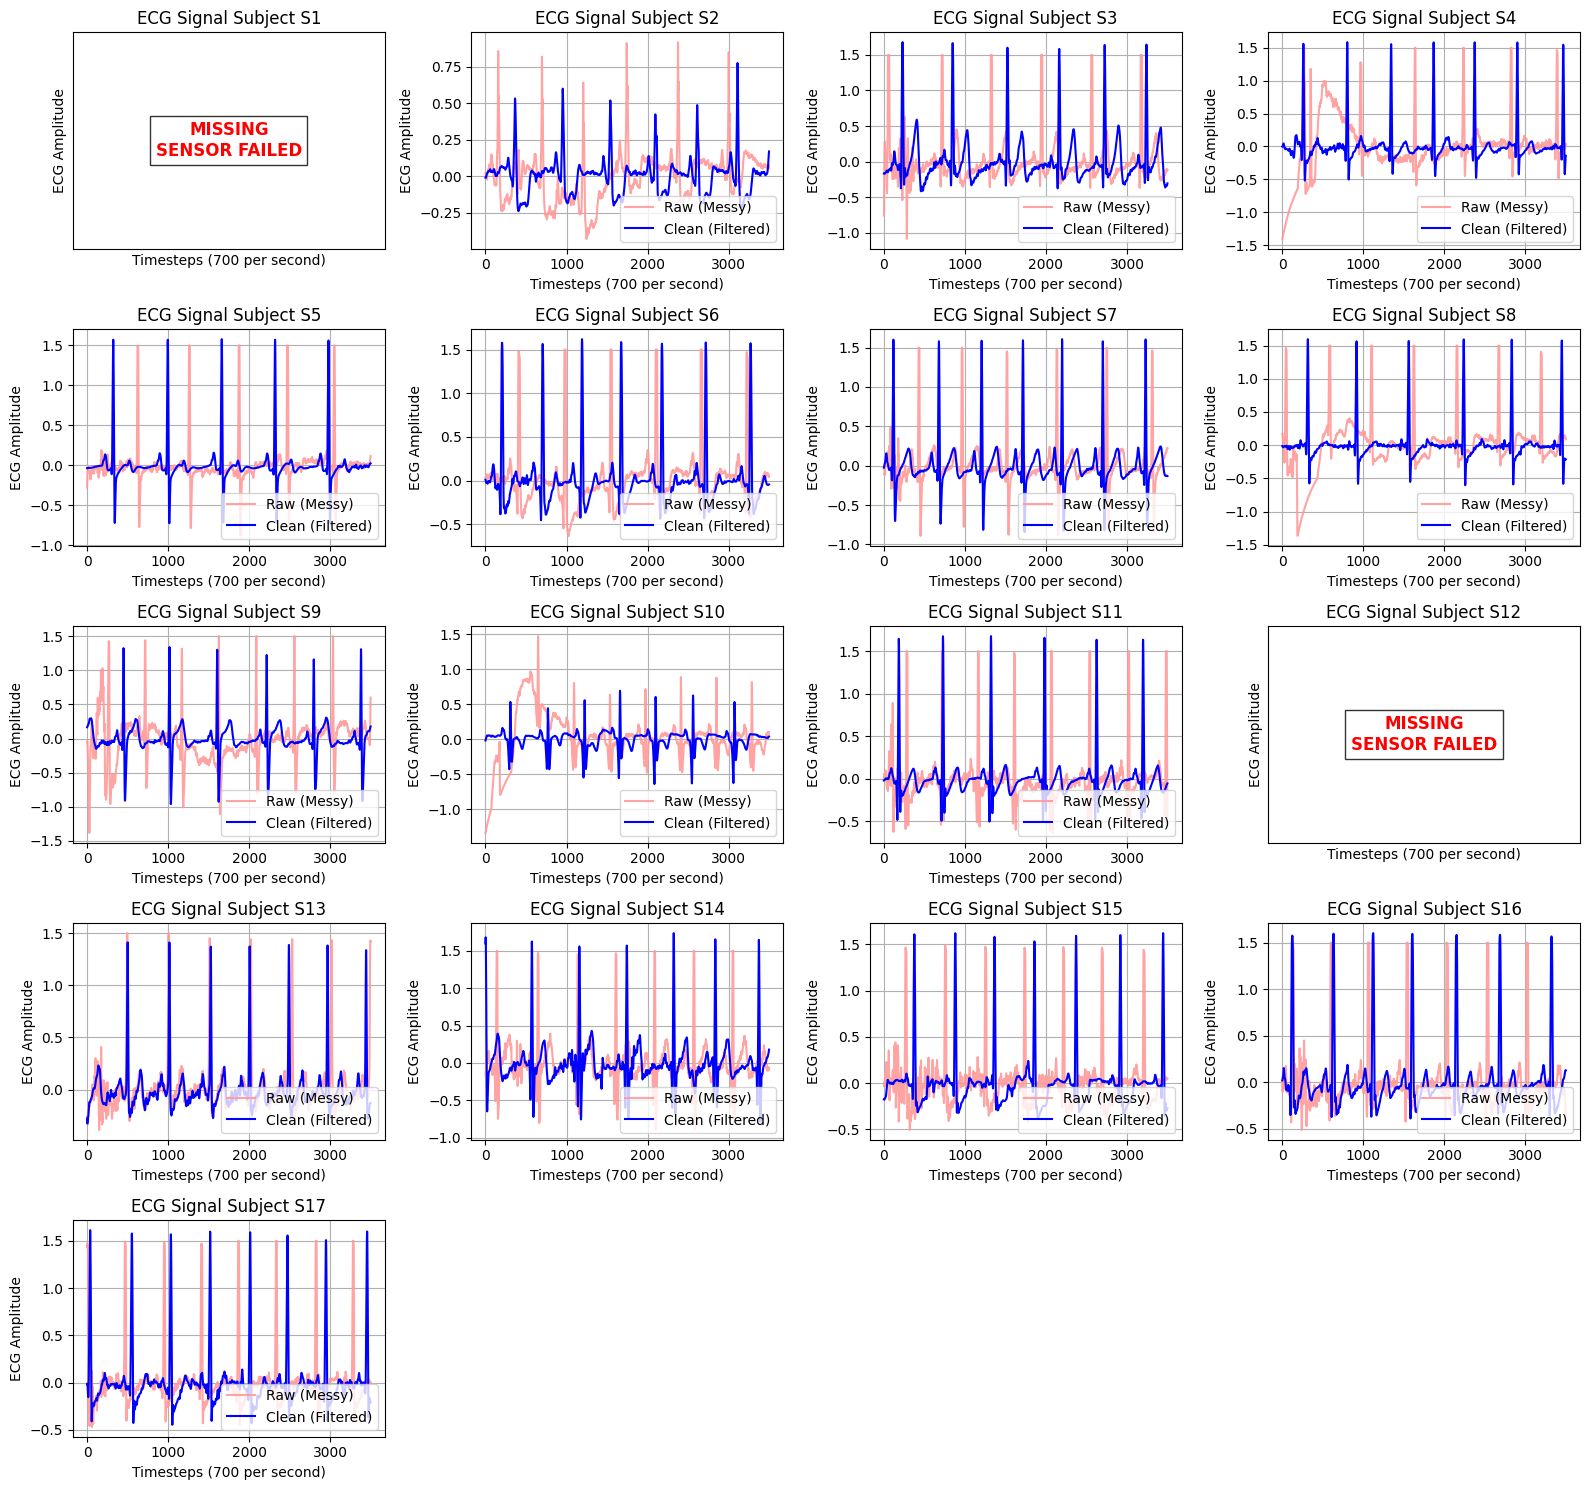

In [ ]:
import pickle
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from scipy import signal

def load_data(file_path):
    with open(file_path, 'rb') as f:
        # WESAD uses 'latin1' encoding for its pickles
        data = pickle.load(f, encoding='latin1')

    # Extract ECG from the chest sensor
    raw_ecg_signal = data['signal']['chest']['ECG'].flatten()
    raw_labels = data['label']

    return raw_ecg_signal, raw_labels

def butterworth_filter(raw_signal, low_cut=0.5, high_cut=40.0, fs=700, order=4):
    b, a = signal.butter(N= order, Wn= [low_cut, high_cut], btype ='bandpass', fs= fs)
    clean_signal = signal.filtfilt (b, a, raw_signal)

    return clean_signal

def filter_data_neutral_only(raw_ecg_signal, raw_labels):
    raw_ecg_signal = butterworth_filter(raw_ecg_signal)
    # Filter only for Neutral (1) and Stress (2)
    valid_indices = np.where((raw_labels == 1) | (raw_labels == 2))[0]

    filtered_ecg = raw_ecg_signal[valid_indices]
    filtered_labels = raw_labels[valid_indices]

    # Convert label '2' (Stress) to 1, and '1' (Neutral) to 0 for Binary Classification
    filtered_labels = np.where(filtered_labels == 2, 1, 0)

    return filtered_ecg, filtered_labels

def filter_data_neutral_amusement_meditation(raw_ecg_signal, raw_labels):
    raw_ecg_signal = butterworth_filter(raw_ecg_signal)
    # Filter all labels; Neutral (1), Stress (2), Amusement (3), Meditation (4)
    valid_indices = np.where((raw_labels >= 1) & (raw_labels <= 4))[0]

    filtered_ecg = raw_ecg_signal[valid_indices]
    filtered_labels = raw_labels[valid_indices]

    # Convert label '2' (Stress) to 1, and all other labels to 0 for Binary Classification
    filtered_labels = np.where(filtered_labels == 2, 1, 0)

    return filtered_ecg, filtered_labels


subjects = []
total_subjects = 17
exclude_subjects = {1, 12} # Subjects 1 and 12

columns = 4
rows = (total_subjects + columns - 1) // columns
fig, axs = plt.subplots(rows, columns, figsize=(columns * 4, rows * 3))
axs = np.atleast_2d(axs)
seconds_to_plot = 5
timesteps = seconds_to_plot * 700

for i in range(1, total_subjects + 1):
  idx = i - 1
  r = idx // columns
  c = idx % columns
  ax = axs[r, c]

  ax.set_title(f"ECG Signal Subject S{i}")
  ax.set_xlabel("Timesteps (700 per second)")
  ax.set_ylabel("ECG Amplitude")
  ax.grid(True)

  file_path = f"wesad_data/WESAD/S{i}/S{i}.pkl"

  if i in exclude_subjects or not os.path.exists(file_path):
    ax.text(0.5, 0.5, "MISSING\nSENSOR FAILED", color='red',
        fontsize=12, fontweight='bold', ha='center', va='center',
        transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8))
    ax.set_xticks([]); ax.set_yticks([])
    continue

  # loading and preprocessing data
  raw_ecg, raw_labels = load_data(file_path)
  filtered_ecg, filtered_labels = filter_data_neutral_only(raw_ecg, raw_labels)
  subjects.append((filtered_ecg, filtered_labels))

  ax.plot(raw_ecg[:timesteps], color='#ff9999', alpha=0.9, label='Raw (Messy)')
  ax.plot(filtered_ecg[:timesteps], color='blue', linewidth=1.5, label='Clean (Filtered)')

  ax.legend(loc="lower right")

n_plots = rows * columns
for j in range(total_subjects, n_plots):
    r = j // columns
    c = j % columns
    axs[r, c].axis('off')

plt.tight_layout()
plt.show()
  # subjects.append((raw_ecg, raw_labels))

# file_path = 'wesad_data/WESAD/S2/S2.pkl'
# raw_ecg, raw_labels = load_data(file_path)
# filtered_ecg, filtered_labels = filter_data_neutral_only(raw_ecg, raw_labels)

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def process_data(ecg, labels, window_size=7000, step_size=3500):
    # normalize across the whole signal
    scaler = StandardScaler()
    normalized_ecg = scaler.fit_transform(ecg.reshape(-1, 1)).flatten()

    print("ECG Signals normalized successfully.")

    # rolling window
    X, y = [], []
    for start in range(0, len(normalized_ecg) - window_size + 1, step_size):
        window = normalized_ecg[start:start + window_size]
        label = labels[start:start + window_size]
        majority_label = np.bincount(label.astype(int)).argmax()
        X.append(window.reshape(-1, 1))
        y.append(majority_label)

    return np.array(X), np.array(y)

# usage
all_X = []
all_y = []

for subj in subjects:
  ecg, labels = subj
  X, y = process_data(ecg, labels)
  all_X.append(X)
  all_y.append(y)
  X_all = np.concatenate(all_X, axis=0)  # (total_windows, 7000, 1)
  y_all = np.concatenate(all_y, axis=0)  # (total_windows,)

  print(f"X shape: {X.shape}, y shape: {y.shape}")

print(f"Final X shape: {X_all.shape}")
print(f"Final y shape: {y_all.shape}")

ECG Signals normalized successfully.
X shape: (350, 7000, 1), y shape: (350,)
ECG Signals normalized successfully.
X shape: (355, 7000, 1), y shape: (355,)
ECG Signals normalized successfully.
X shape: (357, 7000, 1), y shape: (357,)
ECG Signals normalized successfully.
X shape: (367, 7000, 1), y shape: (367,)
ECG Signals normalized successfully.
X shape: (365, 7000, 1), y shape: (365,)
ECG Signals normalized successfully.
X shape: (364, 7000, 1), y shape: (364,)
ECG Signals normalized successfully.
X shape: (366, 7000, 1), y shape: (366,)
ECG Signals normalized successfully.
X shape: (364, 7000, 1), y shape: (364,)
ECG Signals normalized successfully.
X shape: (380, 7000, 1), y shape: (380,)
ECG Signals normalized successfully.
X shape: (371, 7000, 1), y shape: (371,)
ECG Signals normalized successfully.
X shape: (367, 7000, 1), y shape: (367,)
ECG Signals normalized successfully.
X shape: (370, 7000, 1), y shape: (370,)
ECG Signals normalized successfully.
X shape: (371, 7000, 1), y 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# MODEL TRAINING

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, utils

input_shape = (7000, 1)
kernel_size = 5

model = models.Sequential([
    layers.InputLayer(shape = input_shape),
    layers.Conv1D(8, kernel_size=kernel_size, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=5),
    layers.Dropout(0.5),

    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_65 (Conv1D)              │ (None, 6996, 8)        │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 6996, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_67 (MaxPooling1D) │ (None, 1399, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_111 (Dropout)           │ (None, 1399, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_112 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 16 (64.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
import numpy as np

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Calculate class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.5892 - loss: 0.6653 - val_accuracy: 0.3594 - val_loss: 0.7009
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6938 - loss: 0.6182 - val_accuracy: 0.6224 - val_loss: 0.6739
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7329 - loss: 0.5773 - val_accuracy: 0.7789 - val_loss: 0.6236
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7534 - loss: 0.5413 - val_accuracy: 0.7616 - val_loss: 0.5896
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7614 - loss: 0.5042 - val_accuracy: 0.7598 - val_loss: 0.5498
Epoch 6/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7725 - loss: 0.4879 - val_accuracy: 0.7125 - val_loss: 0.5703
Epoch 7/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7800 - loss: 0.4721 - val_accuracy: 0.6706 - val_loss: 0.5853
Epoch 8/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7869 - loss: 0.4503 - val_accuracy: 0.7589 - 

# MODEL EVALUATION

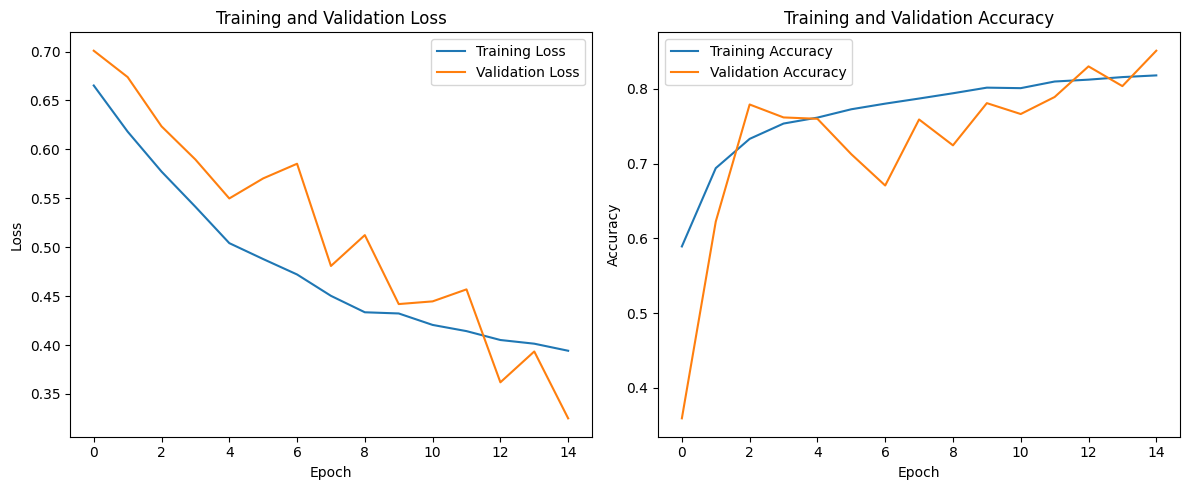

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


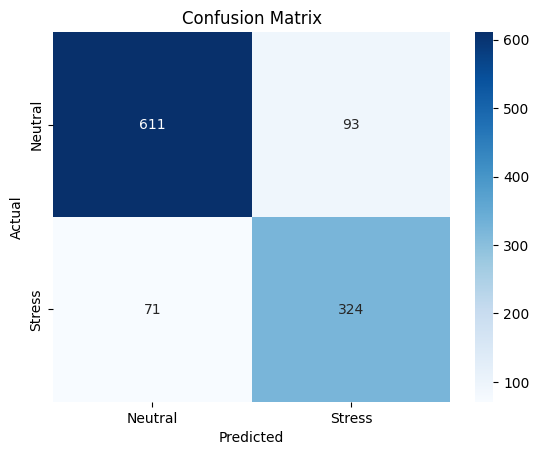

              precision    recall  f1-score   support

     Neutral       0.90      0.87      0.88       704
      Stress       0.78      0.82      0.80       395

    accuracy                           0.85      1099
   macro avg       0.84      0.84      0.84      1099
weighted avg       0.85      0.85      0.85      1099



In [ ]:
# confusion matrix + classification report
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral', 'Stress'],
            yticklabels=['Neutral', 'Stress'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Stress']))